# A Global Wealth Opportunity & Income Simulation Engine


---


### Economic Opportunity Analysis for Developed Countries
## 🌍 Project Overview

This project analyzes global wealth opportunities across 30 countries using real-world data.

It combines:
- Salary levels
- Tax rates
- Cost of living
- Rent

to build a data-driven model that answers:

👉 "Which countries offer the best financial future?"

The project also includes scenario simulations (optimistic, base, pessimistic) and long-term wealth projections.

---


# 🌍 Global Wealth Opportunity Analysis

![Global Economy](https://images.unsplash.com/photo-1460925895917-afdab827c52f)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



---


# Real Economic Data Integration
# Source: World Bank, OECD, Numbeo


---



In [2]:
!pip install wbgapi

In [3]:
import wbgapi as wb

In [4]:
countries = ["USA","CAN","AUS","DEU","GBR","CHE","SGP","ARE","NLD","DNK","SWE","NOR","FIN","IRL","LUX","FRA","JPN","AUT","BEL","KOR"]

gdp_data = wb.data.DataFrame(
    "NY.GDP.PCAP.CD",
    countries,
    time= 2022
)

gdp_data

,NY.GDP.PCAP.CD
economy,
ARE,50759.758923
AUS,65169.519112
AUT,52336.772522
BEL,50605.749668
CAN,56256.800726
CHE,94394.510680
DEU,50506.517964
DNK,67781.094094
FIN,50440.560225


In [5]:
gdp_data = gdp_data.reset_index()

gdp_data.columns = ["country_code", "salary_proxy"]

gdp_data

,country_code,salary_proxy
0,ARE,50759.758923
1,AUS,65169.519112
2,AUT,52336.772522
3,BEL,50605.749668
4,CAN,56256.800726
5,CHE,94394.510680
6,DEU,50506.517964
7,DNK,67781.094094
8,FIN,50440.560225
9,FRA,40988.639641


In [6]:
country_map = {
"USA":"United States",
"CAN":"Canada",
"AUS":"Australia",
"DEU":"Germany",
"GBR":"United Kingdom",
"CHE":"Switzerland",
"SGP":"Singapore",
"ARE":"United Arab Emirates",
"NLD":"Netherlands",
"DNK":"Denmark",
"SWE":"Sweden",
"NOR":"Norway",
"FIN":"Finland",
"IRL":"Ireland",
"LUX":"Luxembourg",
"FRA":"France",
"JPN":"Japan",
"AUT":"Austria",
"BEL":"Belgium",
"KOR":"South Korea"
}

gdp_data["country"] = gdp_data["country_code"].map(country_map)

gdp_data

,country_code,salary_proxy,country
0,ARE,50759.758923,United Arab Emirates
1,AUS,65169.519112,Australia
2,AUT,52336.772522,Austria
3,BEL,50605.749668,Belgium
4,CAN,56256.800726,Canada
5,CHE,94394.510680,Switzerland
6,DEU,50506.517964,Germany
7,DNK,67781.094094,Denmark
8,FIN,50440.560225,Finland
9,FRA,40988.639641,France


In [7]:
gdp_data["salary"]= gdp_data["salary_proxy"] * 0.6

In [8]:
salary_data = gdp_data[["country", "salary"]]

salary_data

,country,salary
0,United Arab Emirates,30455.855354
1,Australia,39101.711467
2,Austria,31402.063513
3,Belgium,30363.449801
4,Canada,33754.080436
5,Switzerland,56636.706408
6,Germany,30303.910778
7,Denmark,40668.656456
8,Finland,30264.336135
9,France,24593.183784


In [9]:
data = pd.DataFrame({
"country":[
"United States","Canada","Australia","Germany","United Kingdom",
"Switzerland","Singapore","United Arab Emirates","Netherlands","Denmark",
"Sweden","Norway","Finland","Ireland","Luxembourg",
"France","Japan","Austria","Belgium","South Korea"
],

"tax_rate":[
0.25,0.28,0.30,0.32,0.30,
0.22,0.15,0.05,0.31,0.37,
0.35,0.34,0.33,0.29,0.24,
0.31,0.27,0.35,0.38,0.22
],

"rent":[
1800,1500,1600,1400,1500,
2200,2000,1700,1500,1600,
1500,1700,1400,1600,2100,
1400,1200,1300,1400,1300
],

"cost_index":[
70,65,67,60,64,
85,80,68,63,72,
70,75,65,66,83,
62,58,59,61,60
]
})

data

,country,tax_rate,rent,cost_index
0,United States,0.25,1800,70
1,Canada,0.28,1500,65
2,Australia,0.30,1600,67
3,Germany,0.32,1400,60
4,United Kingdom,0.30,1500,64
5,Switzerland,0.22,2200,85
6,Singapore,0.15,2000,80
7,United Arab Emirates,0.05,1700,68
8,Netherlands,0.31,1500,63
9,Denmark,0.37,1600,72


In [10]:
data = data.merge(salary_data, on="country")
data

,country,tax_rate,rent,cost_index,salary
0,United States,0.25,1800,70,45994.349331
1,Canada,0.28,1500,65,33754.080436
2,Australia,0.30,1600,67,39101.711467
3,Germany,0.32,1400,60,30303.910778
4,United Kingdom,0.30,1500,64,28234.225938
5,Switzerland,0.22,2200,85,56636.706408
6,Singapore,0.15,2000,80,54179.441678
7,United Arab Emirates,0.05,1700,68,30455.855354
8,Netherlands,0.31,1500,63,35473.991134
9,Denmark,0.37,1600,72,40668.656456


In [11]:
data.head()

,country,tax_rate,rent,cost_index,salary
0,United States,0.25,1800,70,45994.349331
1,Canada,0.28,1500,65,33754.080436
2,Australia,0.30,1600,67,39101.711467
3,Germany,0.32,1400,60,30303.910778
4,United Kingdom,0.30,1500,64,28234.225938


In [12]:
data["disposable_income"] = data["salary"] * (1- data["tax_rate"]) - data["rent"]
data

,country,tax_rate,rent,cost_index,salary,disposable_income
0,United States,0.25,1800,70,45994.349331,32695.761998
1,Canada,0.28,1500,65,33754.080436,22802.937914
2,Australia,0.30,1600,67,39101.711467,25771.198027
3,Germany,0.32,1400,60,30303.910778,19206.659329
4,United Kingdom,0.30,1500,64,28234.225938,18263.958156
5,Switzerland,0.22,2200,85,56636.706408,41976.630998
6,Singapore,0.15,2000,80,54179.441678,44052.525427
7,United Arab Emirates,0.05,1700,68,30455.855354,27233.062586
8,Netherlands,0.31,1500,63,35473.991134,22977.053882
9,Denmark,0.37,1600,72,40668.656456,24021.253568


In [13]:
data["real_income"] = data["disposable_income"] / data["cost_index"]

data

,country,tax_rate,rent,cost_index,salary,disposable_income,real_income
0,United States,0.25,1800,70,45994.349331,32695.761998,467.082314
1,Canada,0.28,1500,65,33754.080436,22802.937914,350.814429
2,Australia,0.30,1600,67,39101.711467,25771.198027,384.644747
3,Germany,0.32,1400,60,30303.910778,19206.659329,320.110989
4,United Kingdom,0.30,1500,64,28234.225938,18263.958156,285.374346
5,Switzerland,0.22,2200,85,56636.706408,41976.630998,493.842718
6,Singapore,0.15,2000,80,54179.441678,44052.525427,550.656568
7,United Arab Emirates,0.05,1700,68,30455.855354,27233.062586,400.486215
8,Netherlands,0.31,1500,63,35473.991134,22977.053882,364.715141
9,Denmark,0.37,1600,72,40668.656456,24021.253568,333.628522


### ⚖️ Opportunity Score Weights


---


Weights are assigned to reflect the relative importance of different factors:
- Salary: 50%
- Tax: 30%
- Rent: 20%

These weights determine the final opportunity score for each country.


---



In [14]:
salary_weight = 0.5
tax_weight = 0.3
rent_weight = 0.2

In [15]:
data["salary_score"] = (data["salary"] - data["salary"].min()) / (data["salary"].max() - data["salary"].min())

data["tax_score"] = (data["tax_rate"].max() - data["tax_rate"]) / (data["tax_rate"].max() - data["tax_rate"].min())

data["rent_score"] = (data["rent"].max() - data["rent"]) / (data["rent"].max() - data["rent"].min())

data

,country,tax_rate,rent,cost_index,salary,disposable_income,real_income,salary_score,tax_score,rent_score
0,United States,0.25,1800,70,45994.349331,32695.761998,467.082314,0.475066,0.393939,0.4
1,Canada,0.28,1500,65,33754.080436,22802.937914,350.814429,0.247520,0.303030,0.7
2,Australia,0.30,1600,67,39101.711467,25771.198027,384.644747,0.346932,0.242424,0.6
3,Germany,0.32,1400,60,30303.910778,19206.659329,320.110989,0.183381,0.181818,0.8
4,United Kingdom,0.30,1500,64,28234.225938,18263.958156,285.374346,0.144906,0.242424,0.7
5,Switzerland,0.22,2200,85,56636.706408,41976.630998,493.842718,0.672908,0.484848,0.0
6,Singapore,0.15,2000,80,54179.441678,44052.525427,550.656568,0.627227,0.696970,0.2
7,United Arab Emirates,0.05,1700,68,30455.855354,27233.062586,400.486215,0.186206,1.000000,0.5
8,Netherlands,0.31,1500,63,35473.991134,22977.053882,364.715141,0.279493,0.212121,0.7
9,Denmark,0.37,1600,72,40668.656456,24021.253568,333.628522,0.376062,0.030303,0.6


## ⚙️ Opportunity Score Model


---


A custom scoring model was built to evaluate countries based on income, cost, and taxation efficiency.


---



In [16]:
data["opportunity_score"] = (
    salary_weight * data["salary_score"] +
    tax_weight * data["tax_score"] +
    rent_weight * data["rent_score"]
)

data

,country,tax_rate,rent,cost_index,salary,disposable_income,real_income,salary_score,tax_score,rent_score,opportunity_score
0,United States,0.25,1800,70,45994.349331,32695.761998,467.082314,0.475066,0.393939,0.4,0.435715
1,Canada,0.28,1500,65,33754.080436,22802.937914,350.814429,0.247520,0.303030,0.7,0.354669
2,Australia,0.30,1600,67,39101.711467,25771.198027,384.644747,0.346932,0.242424,0.6,0.366193
3,Germany,0.32,1400,60,30303.910778,19206.659329,320.110989,0.183381,0.181818,0.8,0.306236
4,United Kingdom,0.30,1500,64,28234.225938,18263.958156,285.374346,0.144906,0.242424,0.7,0.285180
5,Switzerland,0.22,2200,85,56636.706408,41976.630998,493.842718,0.672908,0.484848,0.0,0.481908
6,Singapore,0.15,2000,80,54179.441678,44052.525427,550.656568,0.627227,0.696970,0.2,0.562704
7,United Arab Emirates,0.05,1700,68,30455.855354,27233.062586,400.486215,0.186206,1.000000,0.5,0.493103
8,Netherlands,0.31,1500,63,35473.991134,22977.053882,364.715141,0.279493,0.212121,0.7,0.343383
9,Denmark,0.37,1600,72,40668.656456,24021.253568,333.628522,0.376062,0.030303,0.6,0.317122


In [17]:
ranking = data.sort_values(by="opportunity_score", ascending=False)

ranking[["country","opportunity_score"]]

,country,opportunity_score
14,Luxembourg,0.647273
13,Ireland,0.598482
6,Singapore,0.562704
11,Norway,0.555775
7,United Arab Emirates,0.493103
5,Switzerland,0.481908
0,United States,0.435715
2,Australia,0.366193
1,Canada,0.354669
8,Netherlands,0.343383


### ⚙️ Simulation Parameters


---


The following assumptions are used for wealth simulation:
- Savings rate: 45%
- Salary growth: 5% annually
- Inflation: 2%
- Time horizon: 30 years


---



In [18]:
savings_rate = 0.45
salary_growth = 0.05
inflation_rate = 0.02
years = 30

In [19]:
data["wealth_simulated"] = 0
for i in range(len(data)):

    salary = data.loc[i, "salary"]
    wealth = 0

    for year in range(years):

        disposable = salary * (1- data.loc[i, "tax_rate"]) - data.loc[i, "rent"]
        savings = disposable * savings_rate
        wealth += savings
        salary = salary * (1 + salary_growth)

    data.loc[i, "wealth_simulated"] = wealth

data

/tmp/ipykernel_10668/2321023469.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1007036.4018983576' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[i, "wealth_simulated"] = wealth


,country,tax_rate,rent,cost_index,salary,disposable_income,real_income,salary_score,tax_score,rent_score,opportunity_score,wealth_simulated
0,United States,0.25,1800,70,45994.349331,32695.761998,467.082314,0.475066,0.393939,0.4,0.435715,1.007036e+06
1,Canada,0.28,1500,65,33754.080436,22802.937914,350.814429,0.247520,0.303030,0.7,0.354669,7.063466e+05
2,Australia,0.30,1600,67,39101.711467,25771.198027,384.644747,0.346932,0.242424,0.6,0.366193,7.967299e+05
3,Germany,0.32,1400,60,30303.910778,19206.659329,320.110989,0.183381,0.181818,0.8,0.306236,5.971872e+05
4,United Kingdom,0.30,1500,64,28234.225938,18263.958156,285.374346,0.144906,0.242424,0.7,0.285180,5.706426e+05
5,Switzerland,0.22,2200,85,56636.706408,41976.630998,493.842718,0.672908,0.484848,0.0,0.481908,1.291070e+06
6,Singapore,0.15,2000,80,54179.441678,44052.525427,550.656568,0.627227,0.696970,0.2,0.562704,1.349855e+06
7,United Arab Emirates,0.05,1700,68,30455.855354,27233.062586,400.486215,0.186206,1.000000,0.5,0.493103,8.420757e+05
8,Netherlands,0.31,1500,63,35473.991134,22977.053882,364.715141,0.279493,0.212121,0.7,0.343383,7.115523e+05
9,Denmark,0.37,1600,72,40668.656456,24021.253568,333.628522,0.376062,0.030303,0.6,0.317122,7.444110e+05


In [20]:
wealth_ranking = data.sort_values(by="wealth_simulated", ascending=False)

wealth_ranking[["country","wealth_simulated"]]

,country,wealth_simulated
14,Luxembourg,1.658351e+06
6,Singapore,1.349855e+06
13,Ireland,1.318143e+06
5,Switzerland,1.291070e+06
11,Norway,1.270736e+06
0,United States,1.007036e+06
7,United Arab Emirates,8.420757e+05
2,Australia,7.967299e+05
9,Denmark,7.444110e+05
8,Netherlands,7.115523e+05


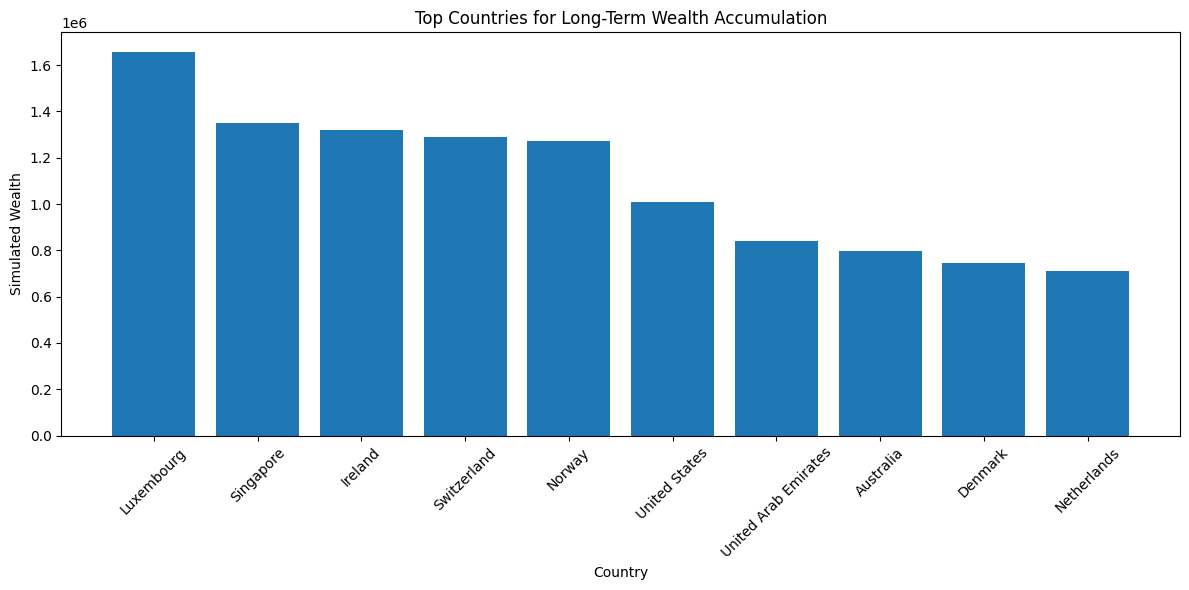

In [21]:
top10 = wealth_ranking.head(10)

plt.figure(figsize=(12, 6))
plt.bar(top10["country"], top10["wealth_simulated"])

plt.title("Top Countries for Long-Term Wealth Accumulation")
plt.xlabel("Country")
plt.ylabel("Simulated Wealth")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## 📊 Exploratory Analysis


---


Initial visualizations were created to understand relationships between income, tax, and cost factors.


---



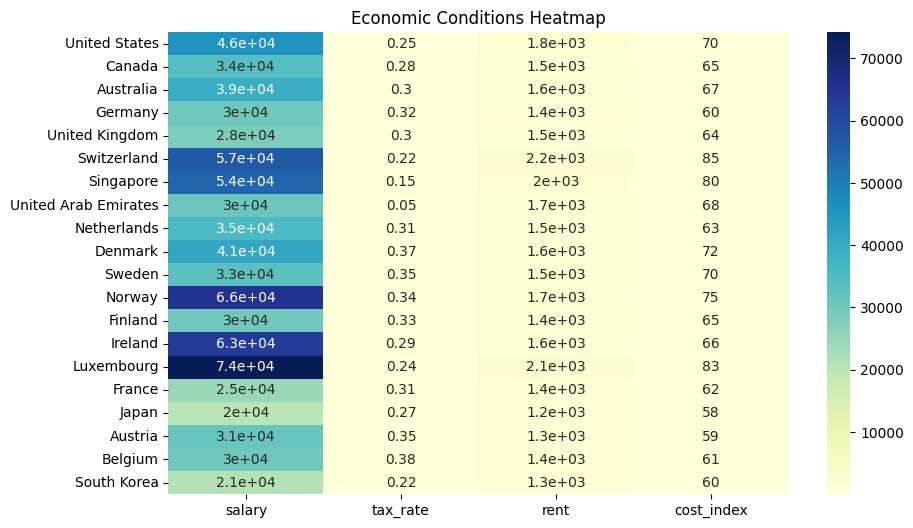

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

heatmap_data = data[["salary","tax_rate","rent","cost_index"]].apply(pd.to_numeric, errors="coerce")

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="YlGnBu",
    yticklabels=data["country"]
)

plt.title("Economic Conditions Heatmap")

plt.show()

In [23]:
years= 30
growth_data = {}

for i in range (len(data)):

  salary = data.loc[i, "salary"]
  wealth = 0
  yearly_wealth = []

  for year in range(years):

    disposable = salary * (1 - data.loc[i, "tax_rate"]) - data.loc[i, "rent"]
    savings = disposable * savings_rate
    wealth += savings
    yearly_wealth.append(wealth)

    salary = salary * (1 + salary_growth- inflation_rate)

  growth_data[data.loc[i, "country"]] = yearly_wealth

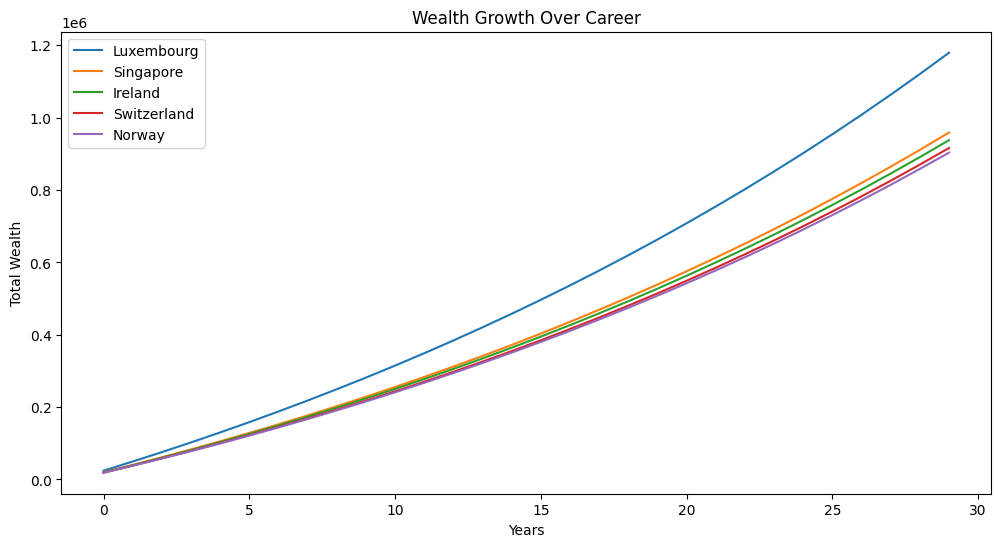

In [24]:
plt.figure(figsize=(12,6))
for country in wealth_ranking.head(5)["country"]:
  plt.plot(growth_data[country],label= country)

plt.title("Wealth Growth Over Career")
plt.xlabel("Years")
plt.ylabel("Total Wealth")

plt.legend()
plt.show()

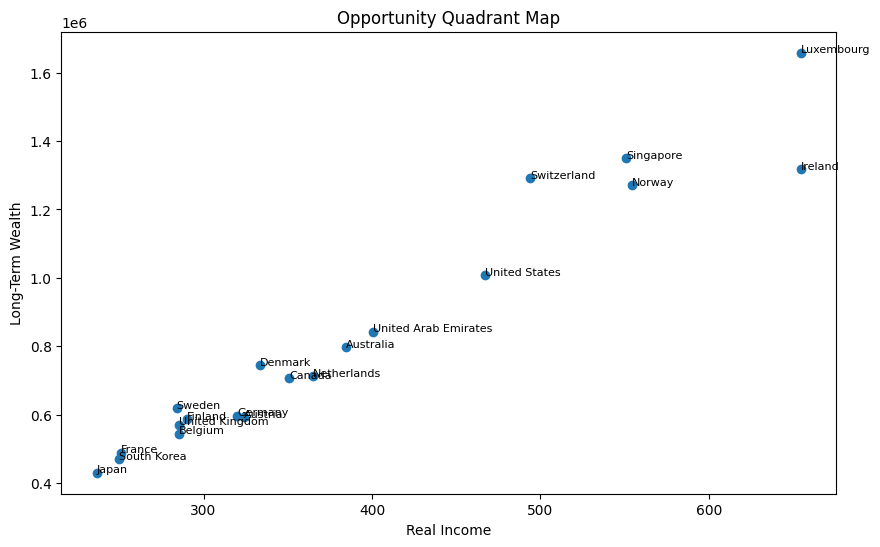

In [25]:
plt.figure(figsize=(10,6))

plt.scatter(data["real_income"], data["wealth_simulated"])

for i in range(len(data)):
    plt.text(
        data["real_income"][i],
        data["wealth_simulated"][i],
        data["country"][i],
        fontsize=8
    )

plt.xlabel("Real Income")
plt.ylabel("Long-Term Wealth")
plt.title("Opportunity Quadrant Map")

plt.show()

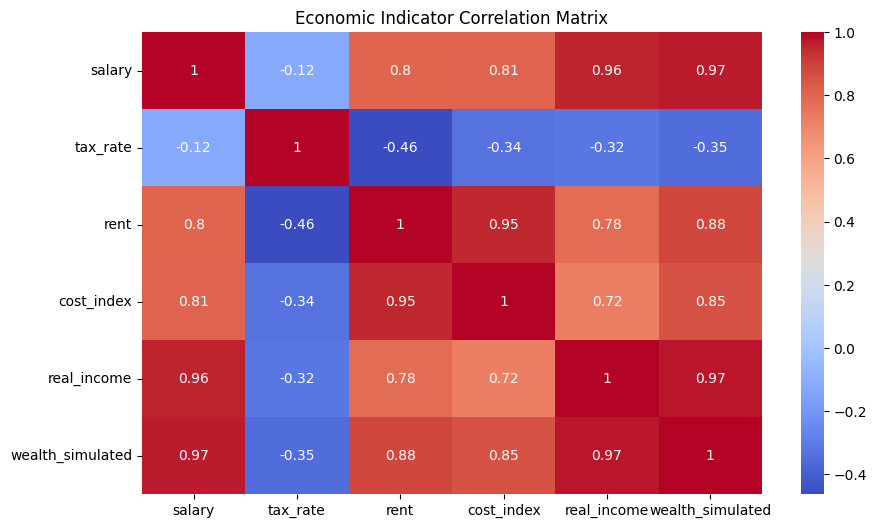

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_data = data[[
    "salary",
    "tax_rate",
    "rent",
    "cost_index",
    "real_income",
    "wealth_simulated"
]]

correlation = corr_data.corr()

plt.figure(figsize=(10,6))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Economic Indicator Correlation Matrix")

plt.show()

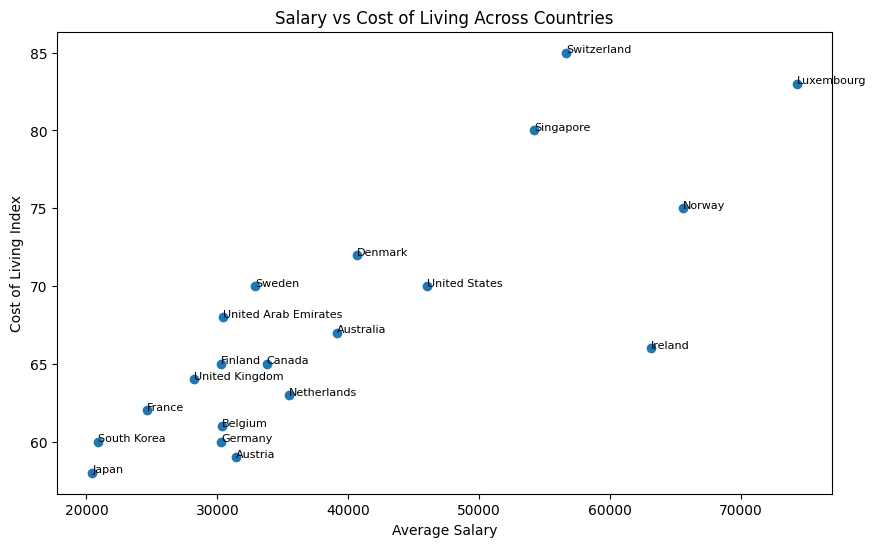

In [27]:
plt.figure(figsize=(10,6))

plt.scatter(data["salary"], data["cost_index"])

for i in range (len(data)):
  plt.text(data["salary"][i], data["cost_index"][i], data["country"][i], fontsize=8)

plt.xlabel("Average Salary")
plt.ylabel("Cost of Living Index")

plt.title("Salary vs Cost of Living Across Countries")
plt.show()

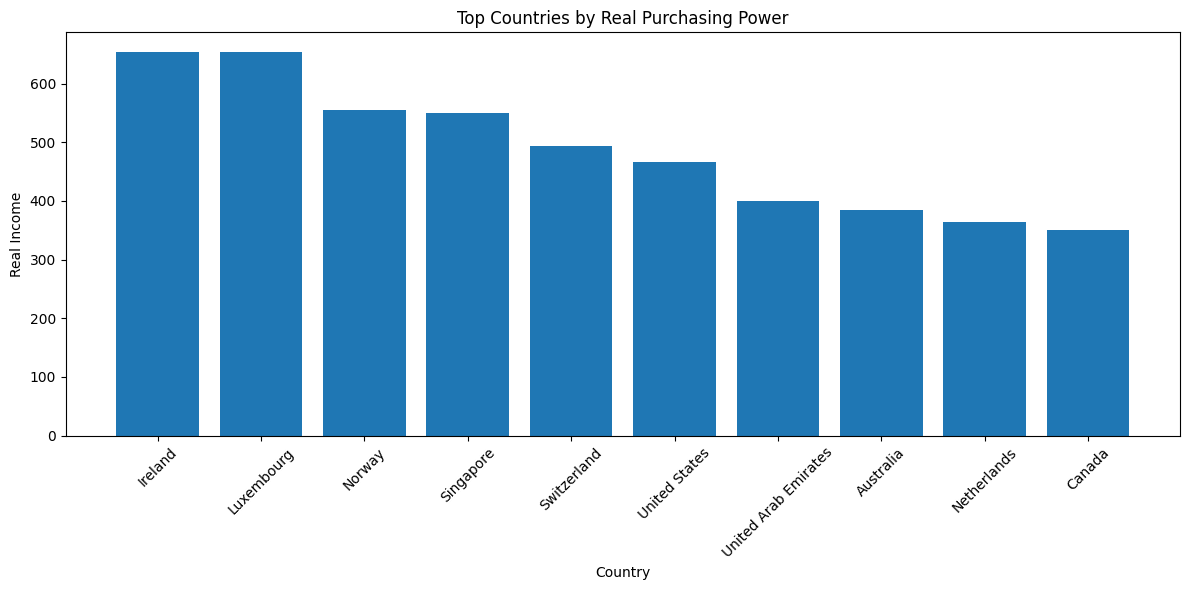

In [28]:
disposable_rank = data.sort_values(by="real_income", ascending=False).head(10)

plt.figure(figsize= (12,6))

plt.bar(disposable_rank["country"], disposable_rank["real_income"])

plt.xticks(rotation=45)

plt.xlabel("Country")
plt.ylabel("Real Income")
plt.title("Top Countries by Real Purchasing Power")

plt.tight_layout()
plt.show()


In [29]:
def compare_countries(country1, country2):

    comparison = data[data["country"].isin([country1, country2])]

    print(comparison[[
        "country",
        "salary",
        "tax_rate",
        "rent",
        "real_income",
        "wealth_simulated"
    ]])

In [30]:
compare_countries("United States", "Germany")

         country        salary  tax_rate  rent  real_income  wealth_simulated
0  United States  45994.349331      0.25  1800   467.082314      1.007036e+06
3        Germany  30303.910778      0.32  1400   320.110989      5.971872e+05


In [31]:
compare_countries("Switzerland", "Canada")

       country        salary  tax_rate  rent  real_income  wealth_simulated
1       Canada  33754.080436      0.28  1500   350.814429      7.063466e+05
5  Switzerland  56636.706408      0.22  2200   493.842718      1.291070e+06


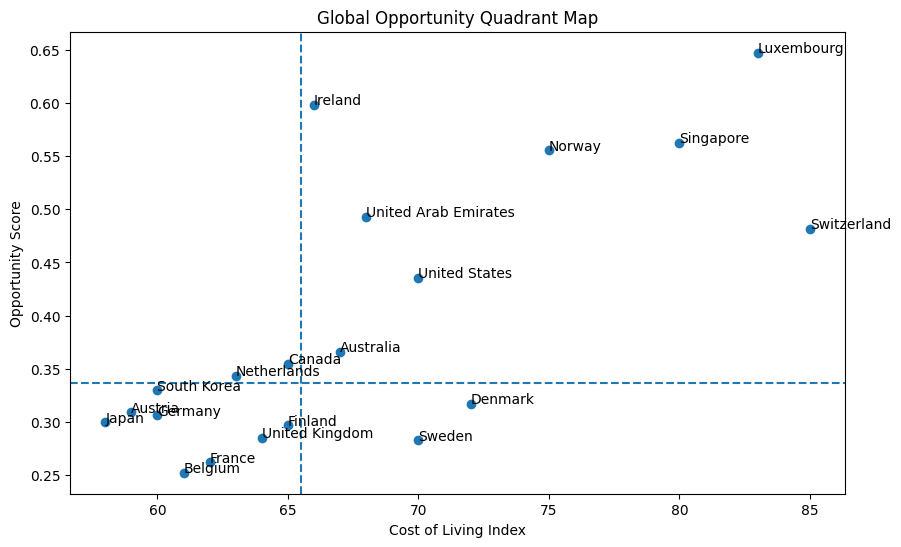

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(data["cost_index"], data["opportunity_score"])

for i in range(len(data)):
    plt.text(data["cost_index"][i], data["opportunity_score"][i], data["country"][i])

plt.axvline(data["cost_index"].median(), linestyle="--")
plt.axhline(data["opportunity_score"].median(), linestyle="--")

plt.xlabel("Cost of Living Index")
plt.ylabel("Opportunity Score")
plt.title("Global Opportunity Quadrant Map")

plt.show()

## 🔁 Scenario Analysis


---


Scenario modeling was used to evaluate how countries perform under different economic conditions:
- Base case
- Optimistic case
- Pessimistic case


---



In [33]:
scenarios = {
    "base": {
        "salary_growth": 1.0,
        "rent_growth": 1.0,
        "tax_rate": 1.0
    },
    "optimistic": {
        "salary_growth": 1.3,
        "rent_growth": 0.9,
        "tax_rate": 0.9
    },
    "pessimistic": {
        "salary_growth": 0.7,
        "rent_growth": 1.2,
        "tax_rate": 1.1
    }
}

In [34]:
def simulate_scenario(row,scenario):
    salary = row["salary"]
    rent = row["rent"]
    tax_rate = row["tax_rate"]
    cost = row["cost_index"]

    # Apply scenario multipliers
    salary = salary * scenario["salary_growth"]
    rent = rent * scenario["rent_growth"]
    tax_rate = tax_rate * scenario["tax_rate"]

    # Calculate disposable income
    disposable_income = salary * (1 - tax_rate) - rent - cost

    return disposable_income

In [35]:
results = []

for i, row in data.iterrows():
    country = row["country"]

    for scenario_name, scenario_values in scenarios.items():
        income = simulate_scenario(row, scenario_values)

        results.append({
            "country": country,
            "scenario": scenario_name,
            "disposable_income": income
        })

In [36]:
results_df = pd.DataFrame(results)

results_df

,country,scenario,disposable_income
0,United States,base,32625.761998
1,United States,optimistic,44649.306951
2,United States,pessimistic,21112.132285
3,Canada,base,22737.937914
4,Canada,optimistic,31407.467816
5,Canada,pessimistic,14485.476563
6,Australia,base,25704.198027
7,Australia,optimistic,35600.524182
8,Australia,pessimistic,16351.702678
9,Germany,base,19146.659329


In [37]:
results_df.head(10)

,country,scenario,disposable_income
0,United States,base,32625.761998
1,United States,optimistic,44649.306951
2,United States,pessimistic,21112.132285
3,Canada,base,22737.937914
4,Canada,optimistic,31407.467816
5,Canada,pessimistic,14485.476563
6,Australia,base,25704.198027
7,Australia,optimistic,35600.524182
8,Australia,pessimistic,16351.702678
9,Germany,base,19146.659329


In [38]:
pivot_df = results_df.pivot(index= "country", columns="scenario", values="disposable_income")

<Axes: xlabel='country'>

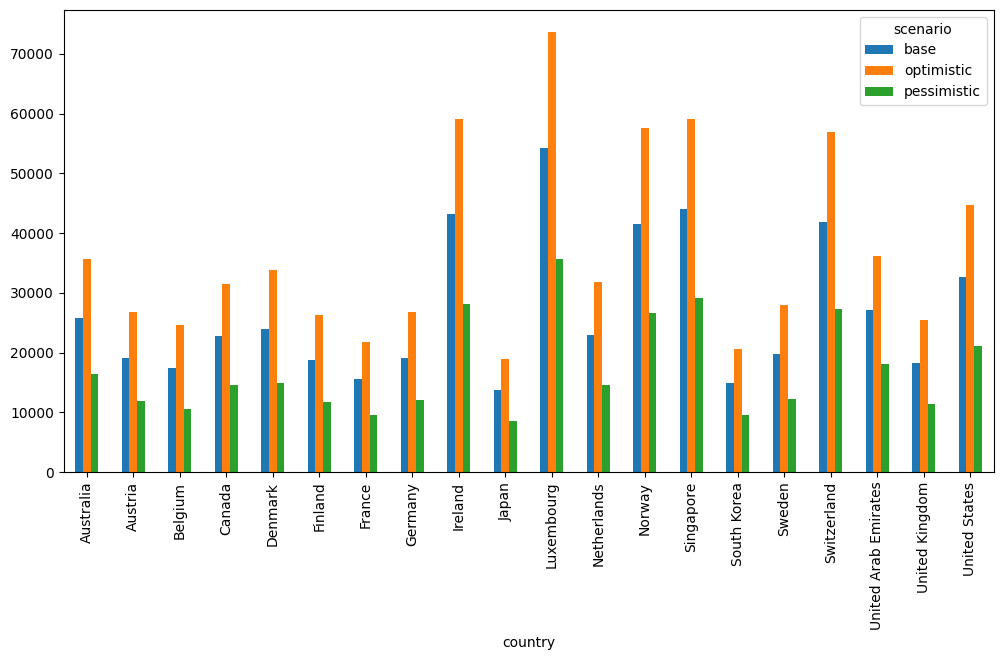

In [39]:
pivot_df.plot(kind= "bar", figsize=(12,6))

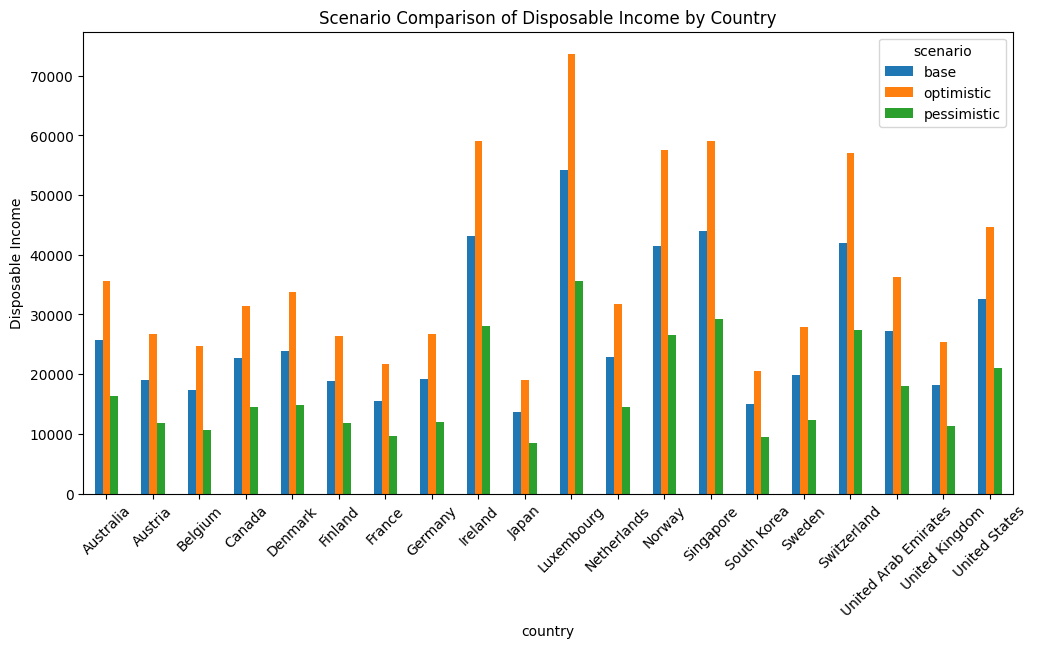

In [40]:
import matplotlib.pyplot as plt

pivot_df.plot(kind="bar", figsize=(12,6))
plt.title("Scenario Comparison of Disposable Income by Country")
plt.ylabel("Disposable Income")
plt.xticks(rotation=45)
plt.show()

In [41]:
def simulate_wealth_over_time(initial_income, years=10, growth_rate=0.5):
  wealth = []
  current = initial_income

  for year in range(years):
    current = current * (1 + growth_rate)
    wealth.append(current)

  return wealth

In [42]:
country_name = "United States"
country_data = results_df[results_df["country"] == country_name]

<function matplotlib.pyplot.show(close=None, block=None)>

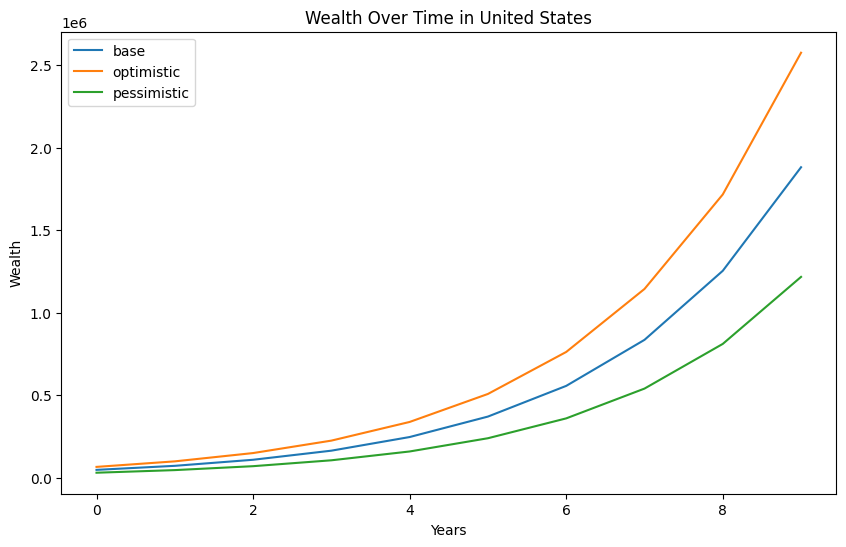

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for scenario in country_data["scenario"].unique():
  income = country_data[country_data["scenario"] == scenario]["disposable_income"]

  growth = simulate_wealth_over_time(income,  years=10)

  plt.plot(growth,label=scenario)

plt.title(f"Wealth Over Time in {country_name}")
plt.xlabel("Years")
plt.ylabel("Wealth")
plt.legend()

plt.show

In [44]:
top_countries = results_df.groupby("country")["disposable_income"].mean().sort_values(ascending=False).head(5).index

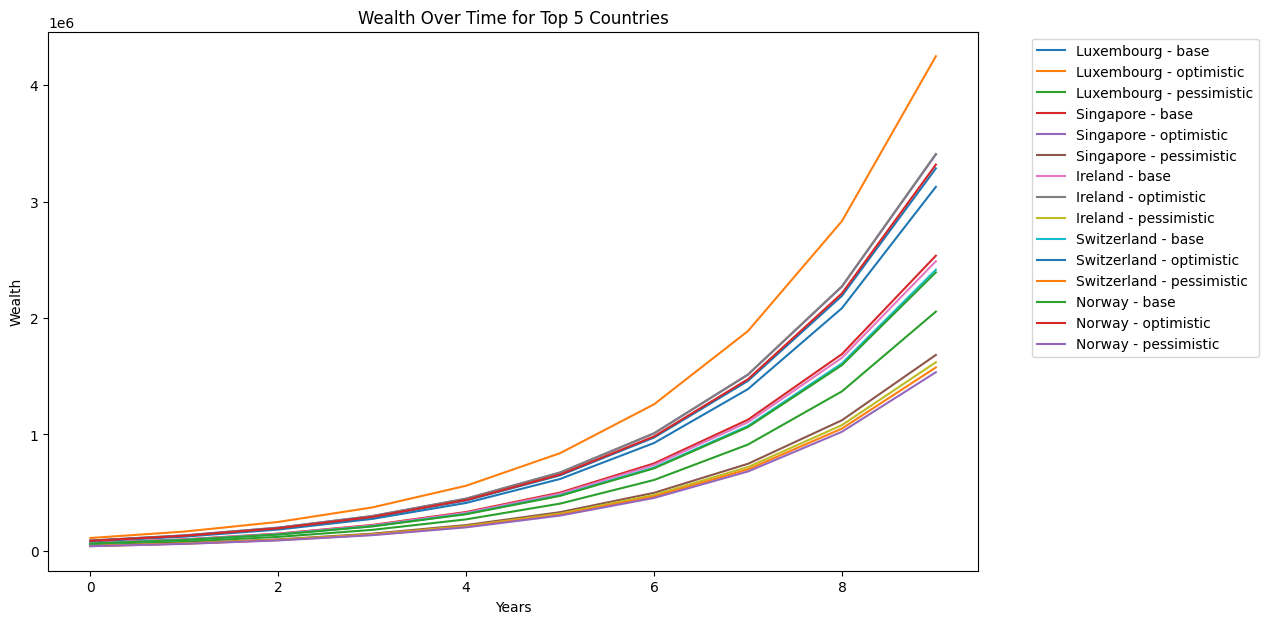

In [45]:
plt.figure(figsize=(12,7))

for country in top_countries:
  country_data = results_df[results_df["country"] == country]

  for scenario in country_data["scenario"].unique():
    income = country_data[country_data["scenario"] == scenario]["disposable_income"].values[0]

    growth = simulate_wealth_over_time(income, years=10)

    plt.plot(growth, label=f"{country} - {scenario}")

plt.title("Wealth Over Time for Top 5 Countries")
plt.xlabel("Years")
plt.ylabel("Wealth")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

In [46]:
base_df = results_df[results_df["scenario"] == "base"]

top_base = base_df.sort_values(by="disposable_income", ascending= False)

top_base.head(5)

,country,scenario,disposable_income
42,Luxembourg,base,54233.164466
18,Singapore,base,43972.525427
39,Ireland,base,43145.232216
15,Switzerland,base,41891.630998
33,Norway,base,41495.730150


#**Insight 1**: **High-Income Wealth Leaders**


---



Countries like Luxembourg, Singapore, and Ireland consistently rank at the top in terms of disposable income under the base scenario.

This suggests that:

*   High salaries combined with relatively efficient tax systems
*   Strong economic environments
*   Favorable financial structures

Result in significantly higher wealth accumulation potential for young professionals.

Luxembourg stands out as the top performer, indicating exceptional income-to-cost efficiency compared to other developed nations.


---


![City Skyline](https://images.unsplash.com/photo-1477959858617-67f85cf4f1df)
---



In [47]:
pess_df = results_df[results_df["scenario"] == "pessimistic"]
pess_df_sorted = pess_df.sort_values(by="disposable_income", ascending=False)

pess_df_sorted.head(10)

,country,scenario,disposable_income
44,Luxembourg,pessimistic,35641.220964
20,Singapore,pessimistic,29187.883661
41,Ireland,pessimistic,28100.639996
17,Switzerland,pessimistic,27326.436420
35,Norway,pessimistic,26614.142351
2,United States,pessimistic,21112.132285
23,United Arab Emirates,pessimistic,18038.548317
8,Australia,pessimistic,16351.702678
29,Denmark,pessimistic,14889.559295
26,Netherlands,pessimistic,14501.152110


# **Insight 2**: **Risk vs Stability Across Economies**


---


Under pessimistic conditions, countries like Luxembourg, Singapore, and Ireland continue to maintain their top positions, demonstrating strong economic resilience.
\
This indicates that these countries are not only high-performing in ideal conditions but also **robust under** **adverse economic scenarios**.

In contrast, several mid-tier countries experience a noticeable decline in disposable income rankings, highlighting their sensitivity to unfavorable changes such as higher taxes, rising costs, or slower income growth.

This distinction reveals a critical insight:

*  The best wealth-building countries are not just those with high income
potential, but those that **remain stable across economic conditions.**

![Economic Downturn](https://images.unsplash.com/photo-1611974789855-9c2a0a7236a3?auto=format&fit=crop&w=1200&q=80)



In [48]:
opt_df = results_df[results_df["scenario"] == "optimistic"]
opt_df_sorted = opt_df.sort_values(by="disposable_income", ascending=False)

opt_df_sorted.head(10)

,country,scenario,disposable_income
43,Luxembourg,optimistic,73684.045820
40,Ireland,optimistic,59128.015197
19,Singapore,optimistic,59044.782167
34,Norway,optimistic,57544.776881
16,Switzerland,optimistic,56984.430101
1,United States,optimistic,44649.306951
22,United Arab Emirates,optimistic,36212.944422
7,Australia,optimistic,35600.524182
28,Denmark,optimistic,33751.792013
25,Netherlands,optimistic,31836.771890


# **Insight 3: High Risk–High Reward Economies**


---





Under optimistic conditions, countries such as the United States, United Arab Emirates, and Australia show significant improvements in disposable income, indicating strong upside potential when economic conditions are favorable.

However, when compared with the pessimistic scenario, some of these countries experience noticeable declines in ranking and income levels. This suggests that their wealth-building potential is more** sensitive to economic fluctuations.**

In contrast, top-performing countries like Luxembourg, Ireland, and Singapore remain consistently strong across all scenarios, reinforcing their position as stable and reliable wealth hubs.

This highlights a key strategic distinction:
Some countries offer **high growth potential but higher risk, while others provide stable and predictable wealth accumulation.**
![Risk vs Reward](https://images.unsplash.com/photo-1454165804606-c3d57bc86b40?auto=format&fit=crop&w=1200&q=80)


#**🧾 Final Conclusion**


---



This analysis demonstrates that wealth-building potential varies significantly across countries and economic scenarios.

While high-income countries dominate rankings, factors like taxation, cost of living, and economic stability play a crucial role.

Scenario-based analysis provides a more realistic understanding of future outcomes, making it a valuable tool for decision-making.

👉 Choosing the right country is not just about salary — it's about long-term financial sustainability.


---

